In [2]:
import matplotlib as plt

plt.rcParams.update({
    "font.size": 14,        # base font
    "axes.labelsize": 14,   # x and y labels
    "axes.titlesize": 14,   # title
    "legend.fontsize": 14,  
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})
plt.rcParams['figure.dpi'] = 300

In [3]:
from experiments import (
    run_model,
    run_architecture_comparison,
    run_g_scan,
    run_L_scan,
    run_entropy_vs_subsystem_size,
)
from plotting import (
    plot_training_curves,
    plot_g_scan,
    plot_L_scan,
    plot_entropy_profile,
)

In [4]:
from random_state_experiments import compare_architectures_entropy_scaling
from plotting import plot_architecture_entropy_scaling

In [16]:
L = 16

results = compare_architectures_entropy_scaling(
    L=L,
    seeds=range(10),
    subsystem_sizes=None,
    entropy_pairings=16,
    nchains=32,
    nsamples_per_chain=200,
    neq=50,
    nskip=2,
    rbm_hidden=20,
    ffn_hidden_layers=(64, 64),
    cnn_channels=16,
    cnn_kernel=3,
    cnn_n_conv_layers=2,
)

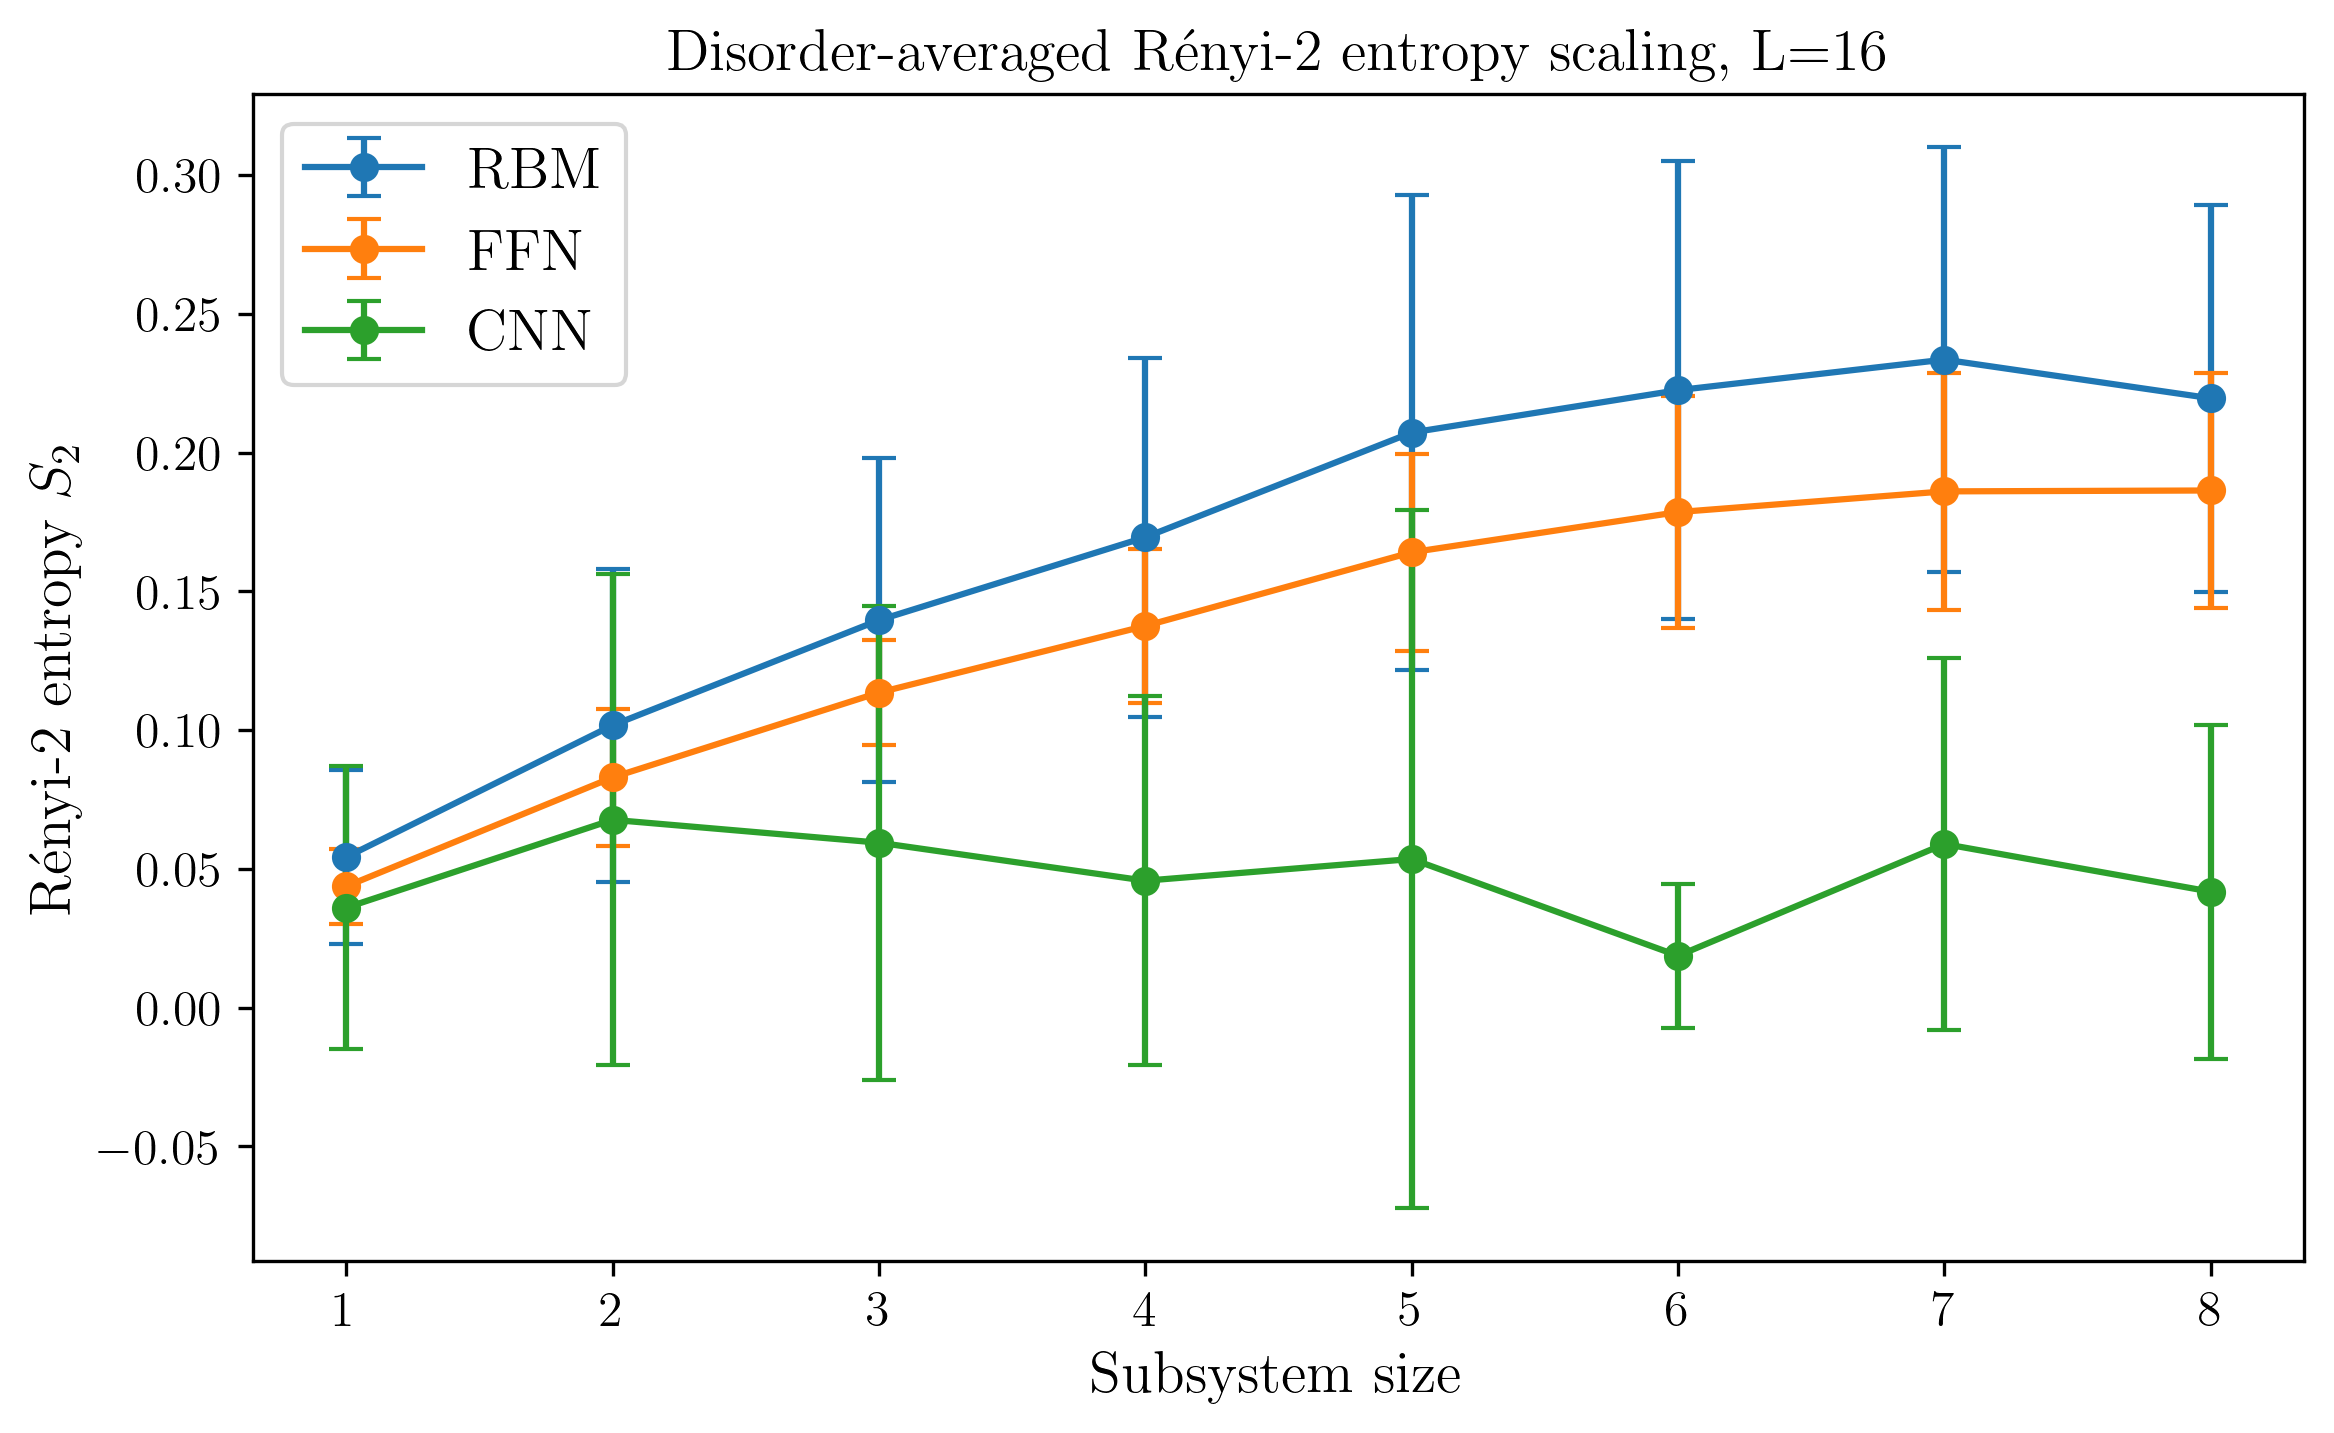

In [17]:
plot_architecture_entropy_scaling(
    results,
    title=f"Disorder-averaged Rényi-2 entropy scaling, L={L}"
)

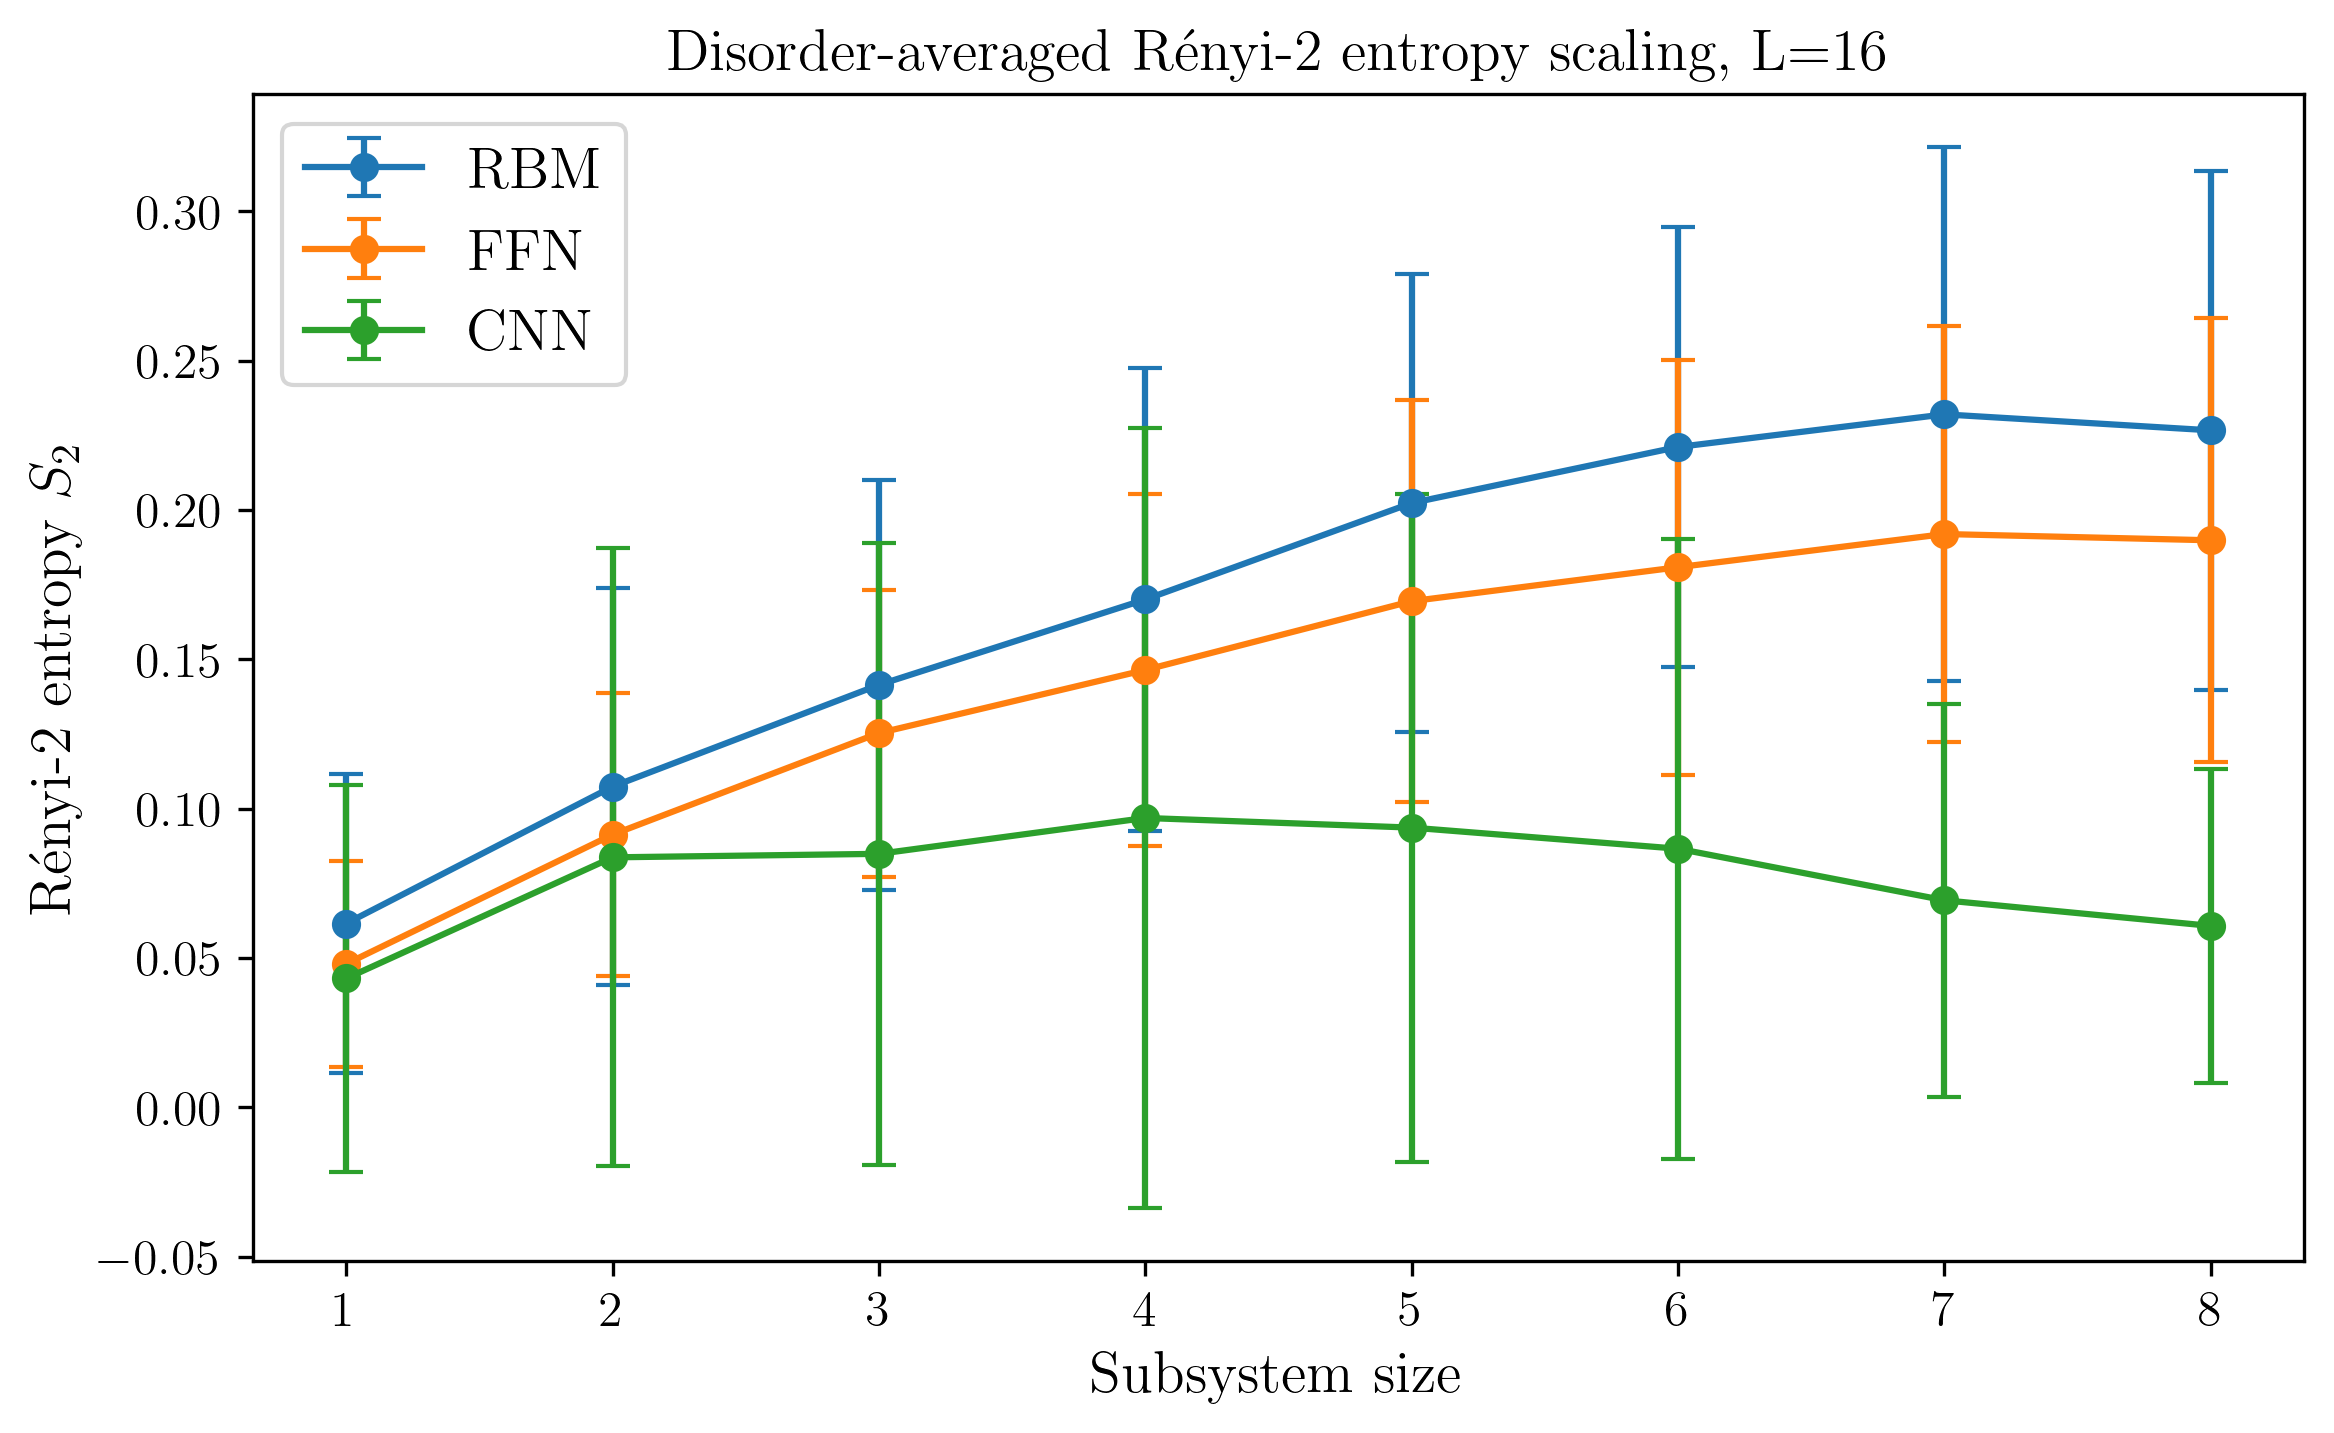

In [9]:
plot_architecture_entropy_scaling(
    results,
    title=f"Disorder-averaged Rényi-2 entropy scaling, L={L}"
)

In [10]:
L = 16
cnn_kernel_2 = 6
results2 = compare_architectures_entropy_scaling(
    L=L,
    seeds=range(30),
    subsystem_sizes=None,
    entropy_pairings=16,
    nchains=32,
    nsamples_per_chain=16,
    neq=50,
    nskip=2,
    rbm_hidden=20,
    ffn_hidden_layers=(32, 32),
    cnn_channels=16,
    cnn_kernel=6,
    cnn_n_conv_layers=2,
)

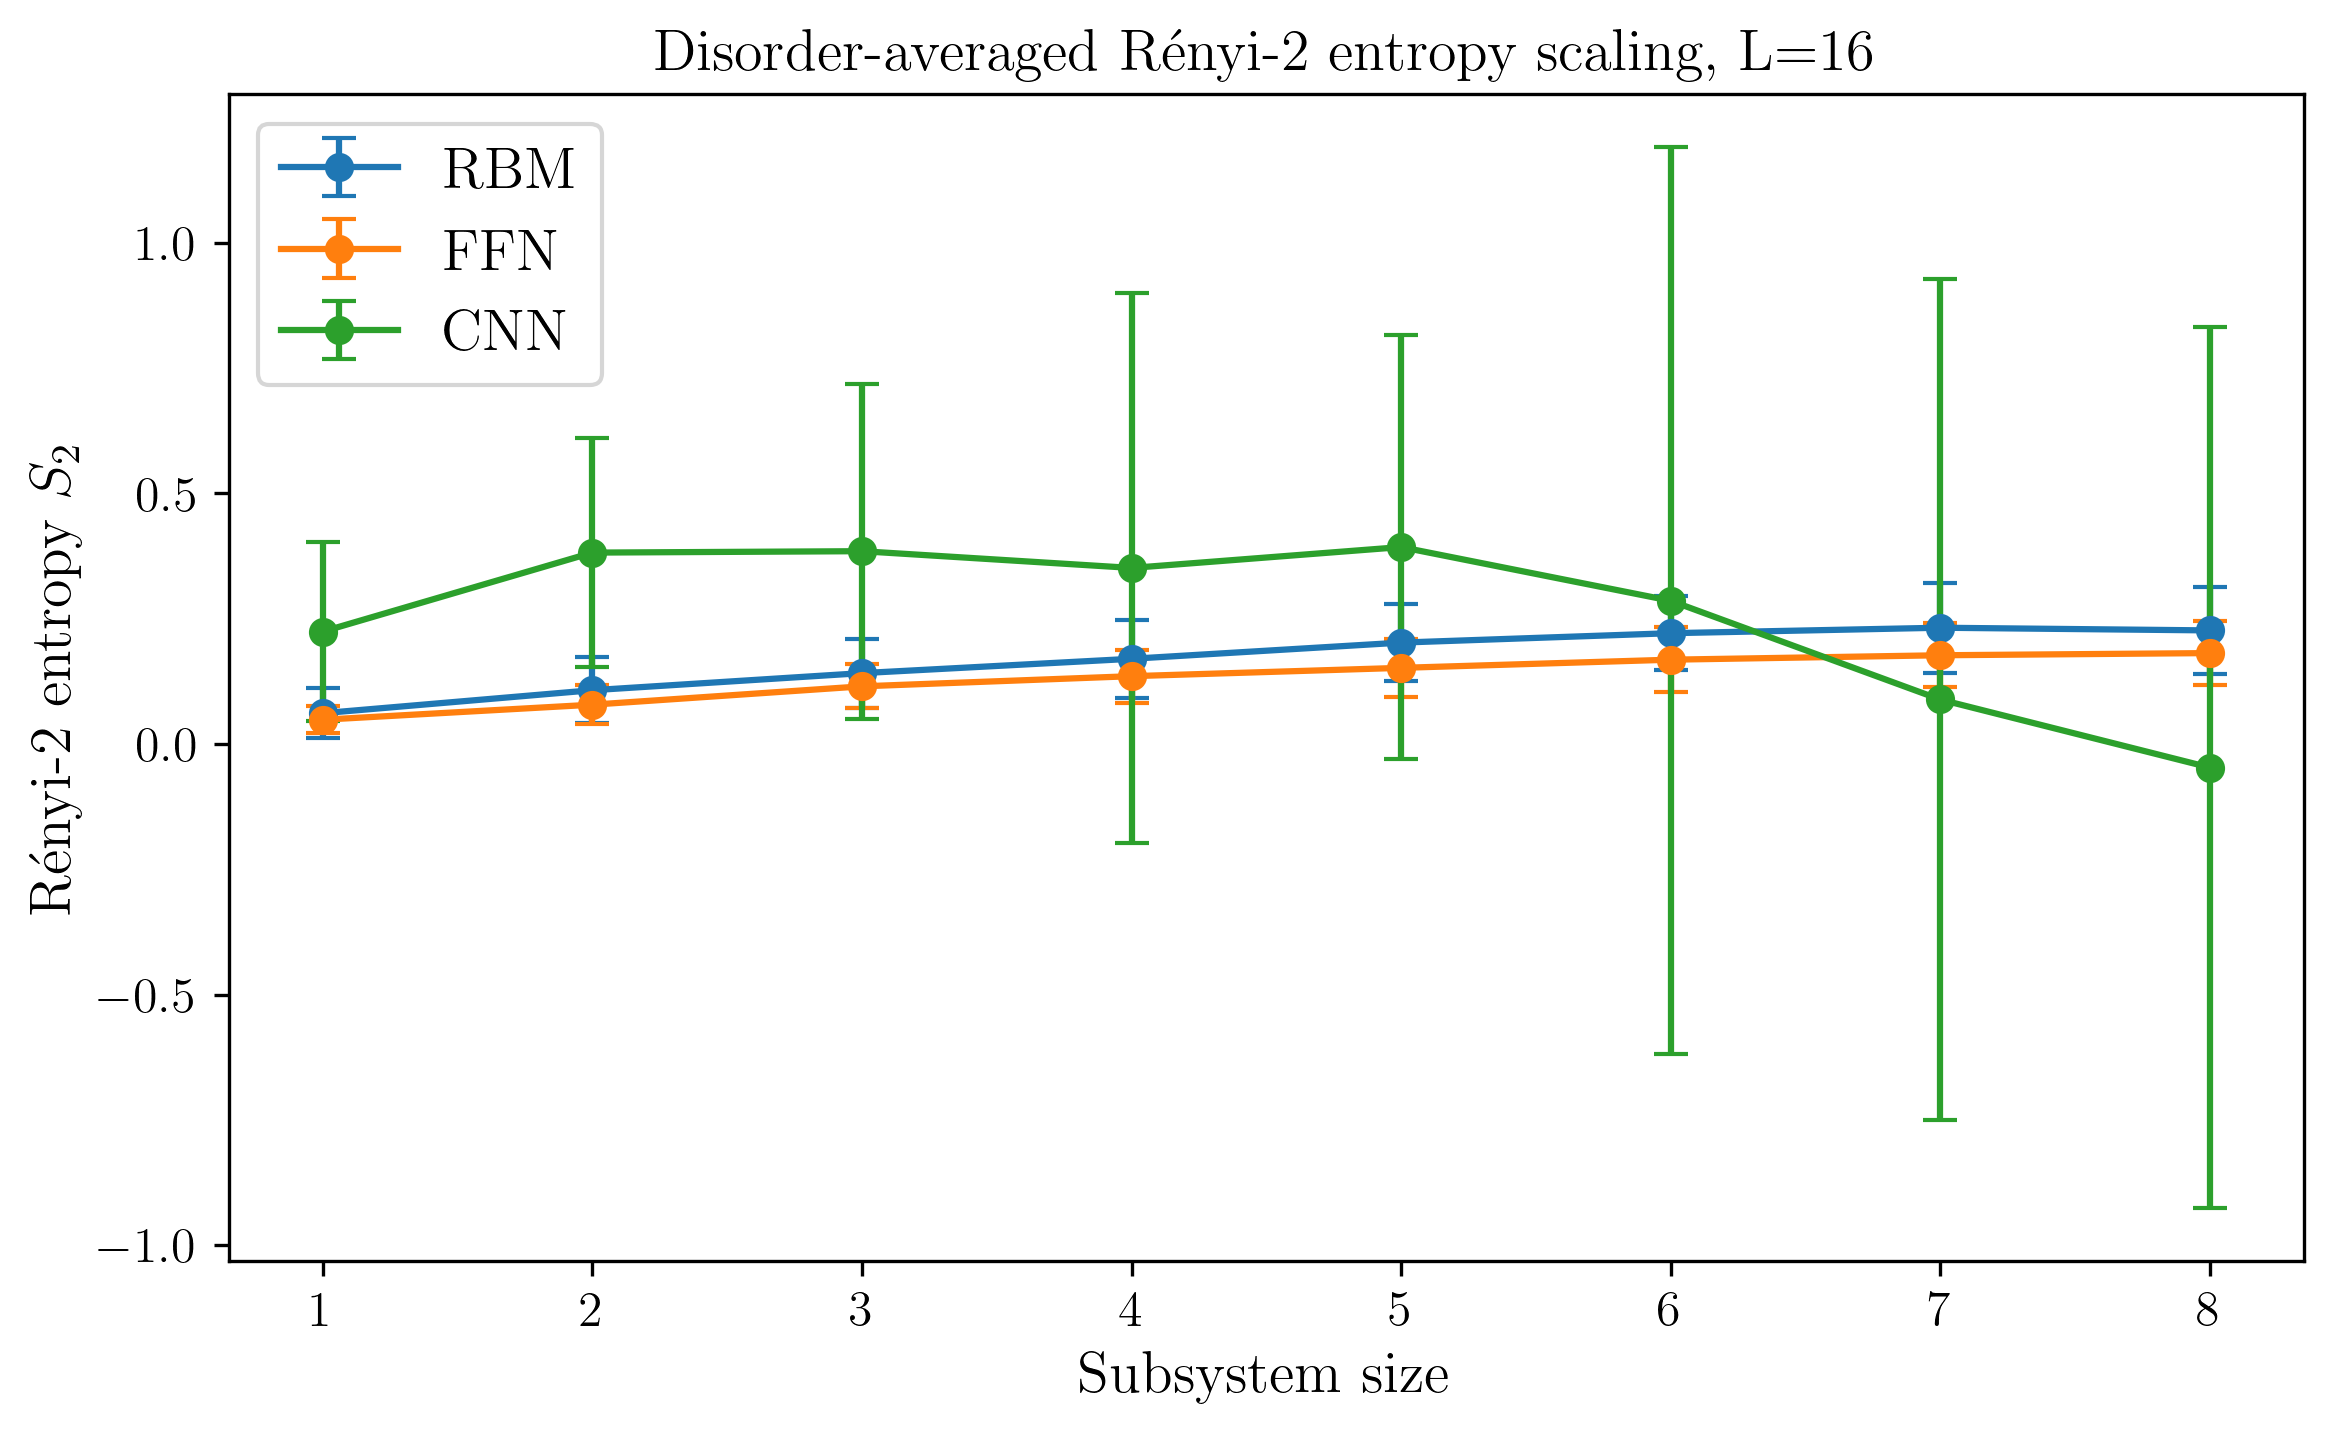

In [11]:
plot_architecture_entropy_scaling(
    results2,
    title=f"Disorder-averaged Rényi-2 entropy scaling, L={L}"
)

# LARGER WEIGHT INITIALIZATION

Weird behaviour of CNN with higher kernels, the swap estimator returns negative values

To examine the CNN, we calculate the exact entropy for small system sizes and compare it with the swap estimated entropy

In [6]:
from random_state_experiments import compare_swap_vs_exact_for_one_model
from plotting import plot_swap_vs_exact_entropy

In [ ]:
L=16
cnn_test = compare_swap_vs_exact_for_one_model(
    "CNN",
    L=16,                         
    seeds=range(10),
    channels=16,
    kernel=3,
    n_conv_layers=5,             # deep CNN
    entropy_pairings=16,
    nchains=32,
    nsamples_per_chain=16,
)

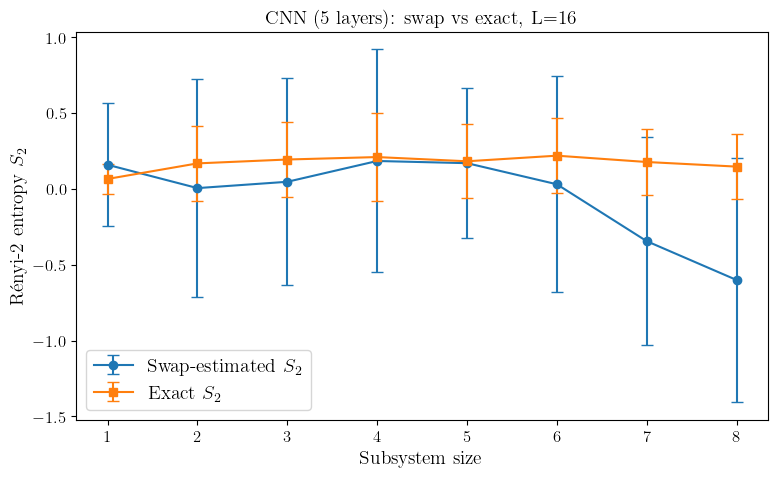

In [5]:
plot_swap_vs_exact_entropy(
    cnn_test,
    title=f"CNN (5 layers): swap vs exact, L={L}"
)

In [ ]:
L=16
cnn_test_3_layers = compare_swap_vs_exact_for_one_model(
    "CNN",
    L=16,                         # small!
    seeds=range(20),
    channels=16,
    kernel=3,
    n_conv_layers=3,             
    entropy_pairings=16,
    nchains=32,
    nsamples_per_chain=16,
)

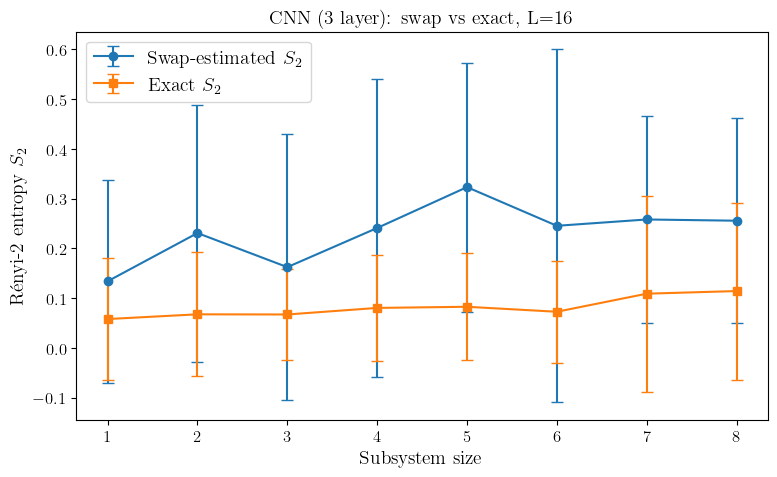

In [ ]:
plot_swap_vs_exact_entropy(
    cnn_test_3_layers,
    title=f"CNN (3 layer): swap vs exact, L={L}"
)

In [ ]:
L=16
cnn_test_1_layer = compare_swap_vs_exact_for_one_model(
    "CNN",
    L=16,                         
    seeds=range(20),
    channels=16,
    kernel=6,
    n_conv_layers=1,             # shallow CNN
    entropy_pairings=36,
    nchains=32,
    nsamples_per_chain=32,
)

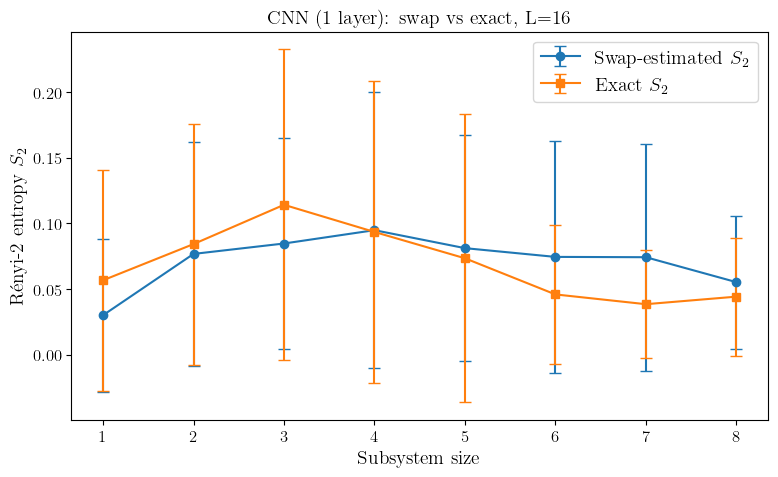

In [8]:
plot_swap_vs_exact_entropy(
    cnn_test_1_layer,
    title=f"CNN (1 layer): swap vs exact, L={L}"
)

In [2]:
from plotting import plot_cnn_depths_swap_vs_exact

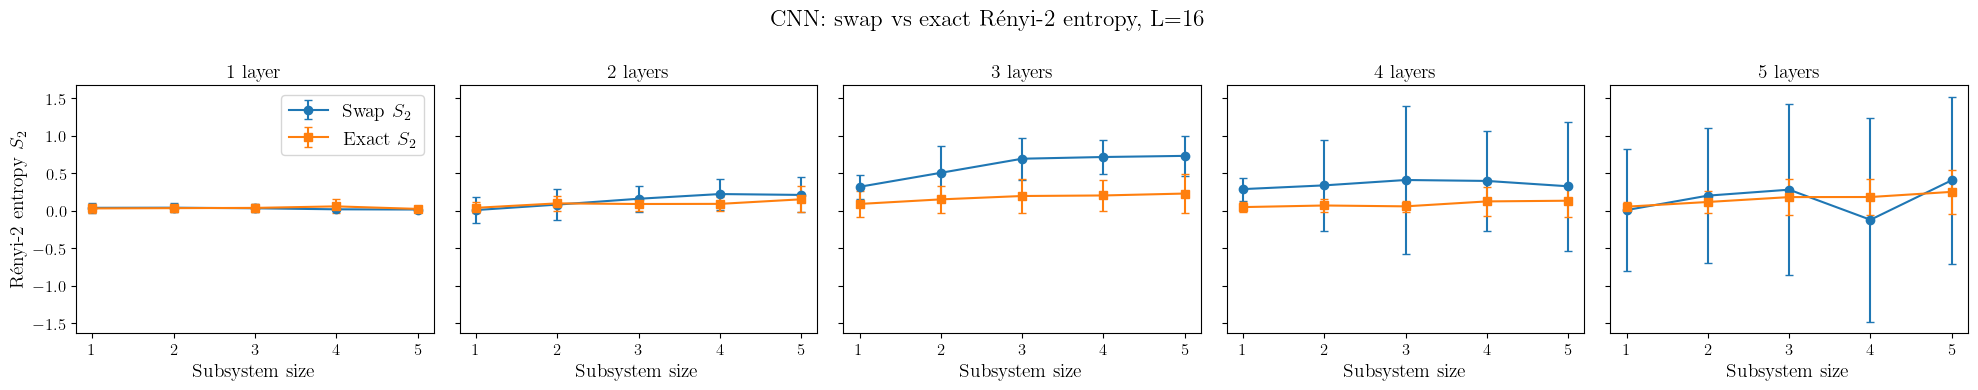

In [3]:
plot_cnn_depths_swap_vs_exact(
    L=16,
    seeds=range(10),
    subsystem_sizes=range(1, 6),
    cnn_channels=16,
    cnn_kernel=4,
    entropy_pairings=16,
)

In [ ]:
from plotting import plot_cnn_entropy_vs_kernel

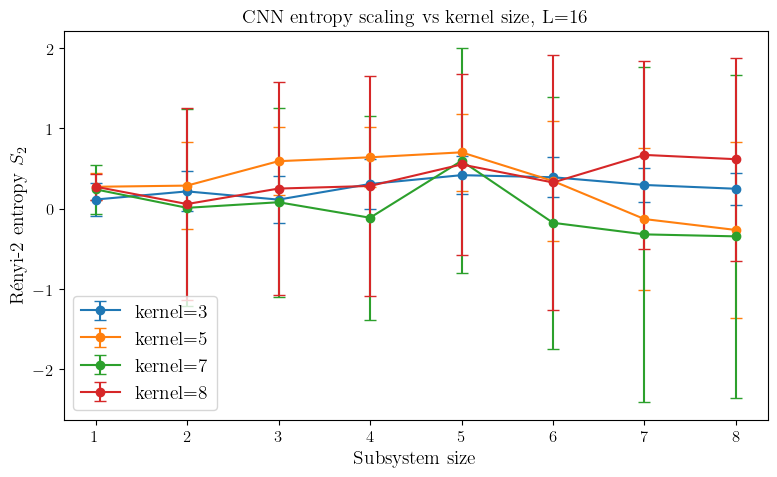

In [8]:
plot_cnn_entropy_vs_kernel(
    L=16,
    seeds=range(10),
    kernel_sizes=(3,5,7,8),
    cnn_channels=16,
    cnn_n_conv_layers=3,
    entropy_pairings=16,
)

# Scaling of entropy with parameter count for RBM, FFN & CNN

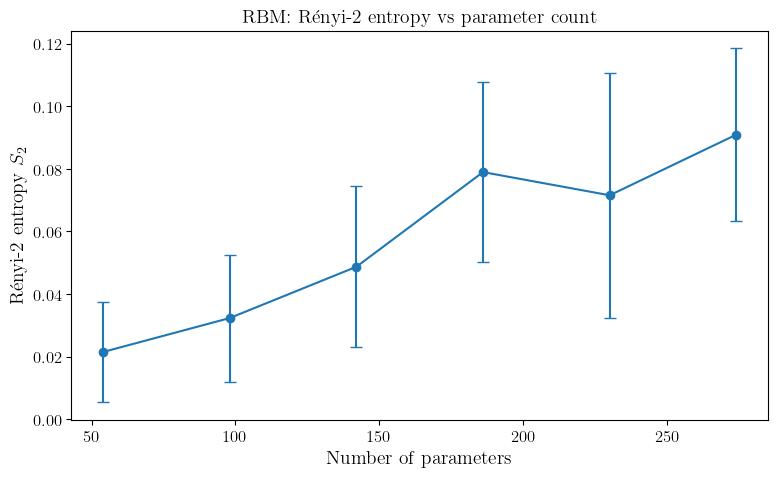

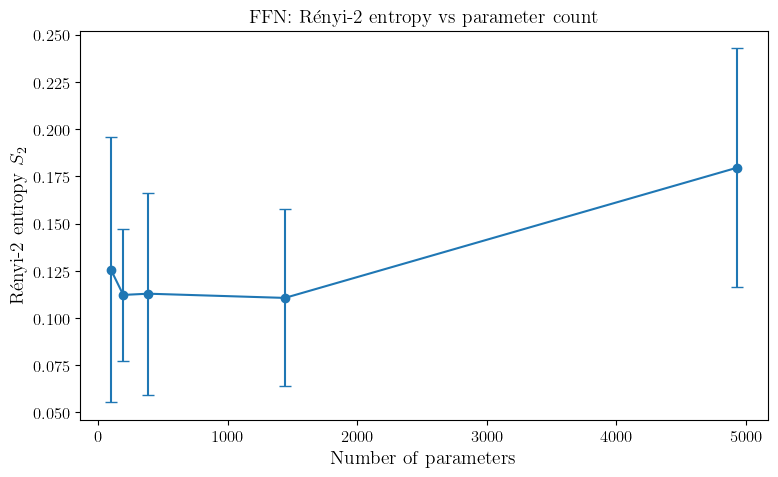

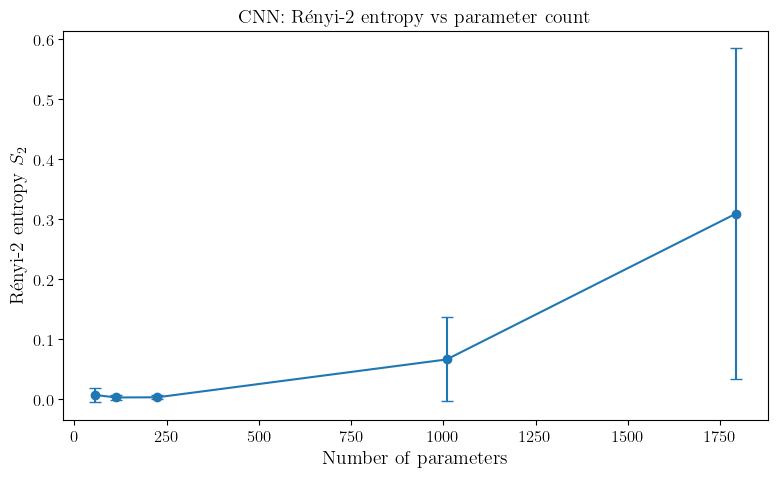

In [ ]:
from random_state_experiments import compare_architectures_entropy_vs_parameter_count
from plotting import plot_entropy_vs_parameter_count
results_param = compare_architectures_entropy_vs_parameter_count(
    L=10,
    seeds=range(10),
    subsystem_size=5,
    entropy_pairings=16,
    rbm_size_values=(4, 8, 12, 16, 20, 24),
    ffn_size_values=((8,), (16,), (32,), (32, 32), (64, 64)),
    cnn_size_values=((4, 1), (8, 1), (16, 1), (16, 2), (16, 3)),
)


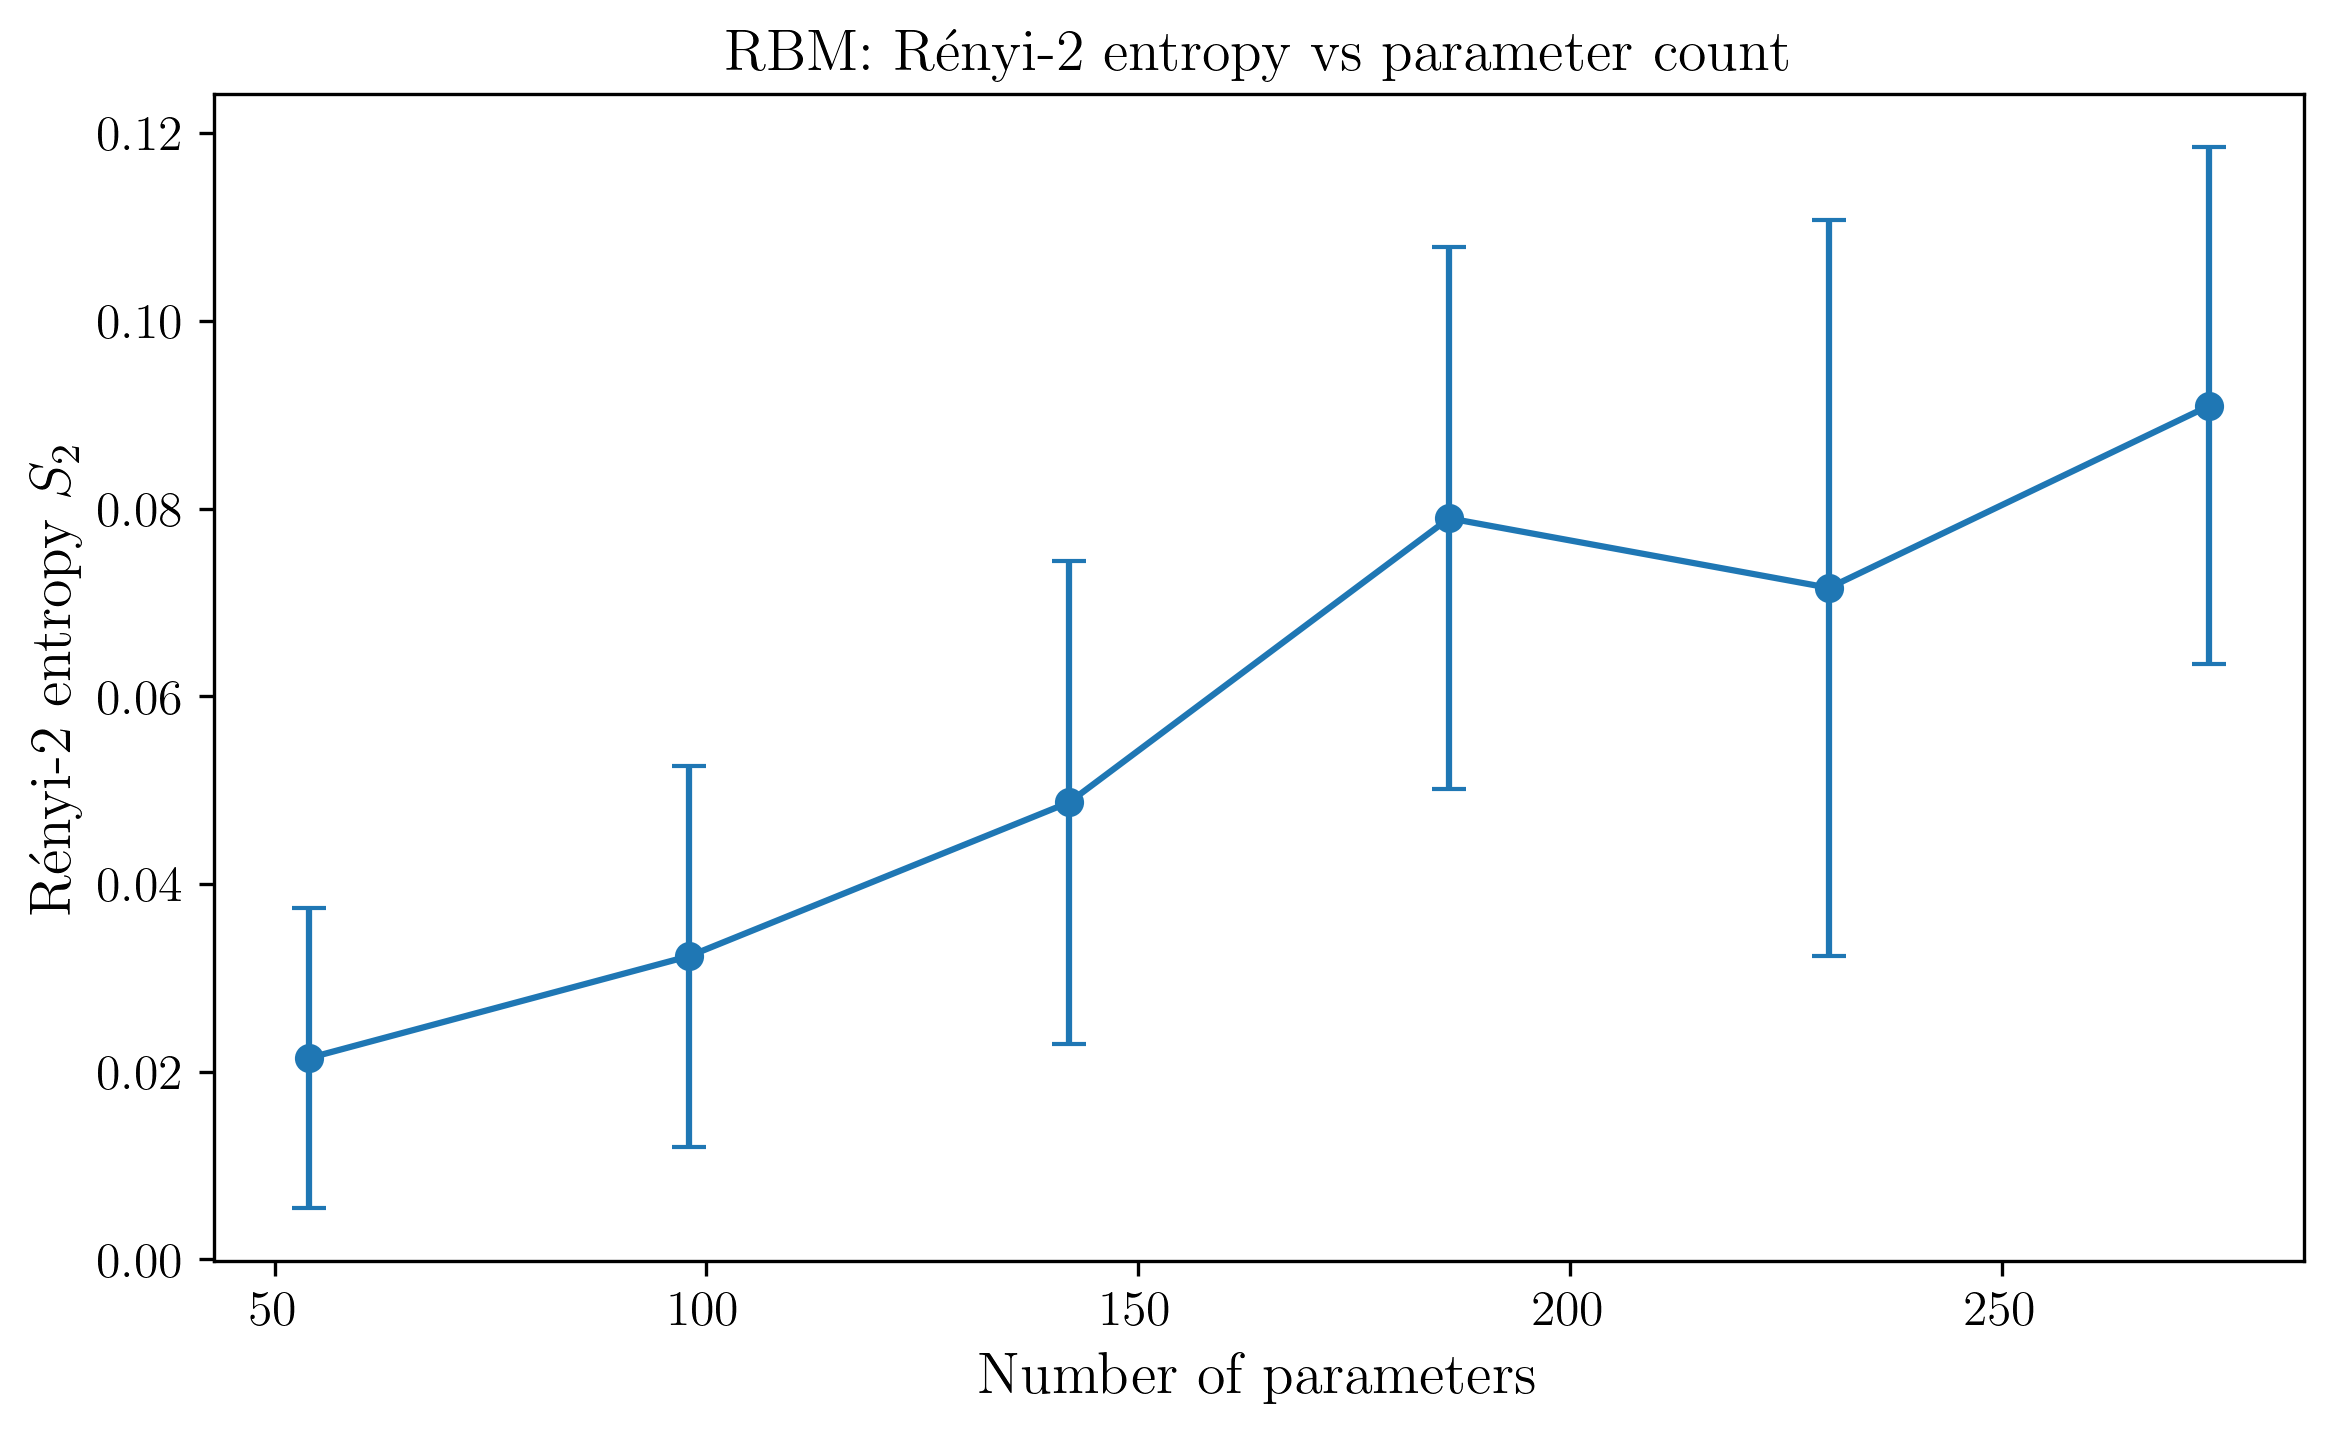

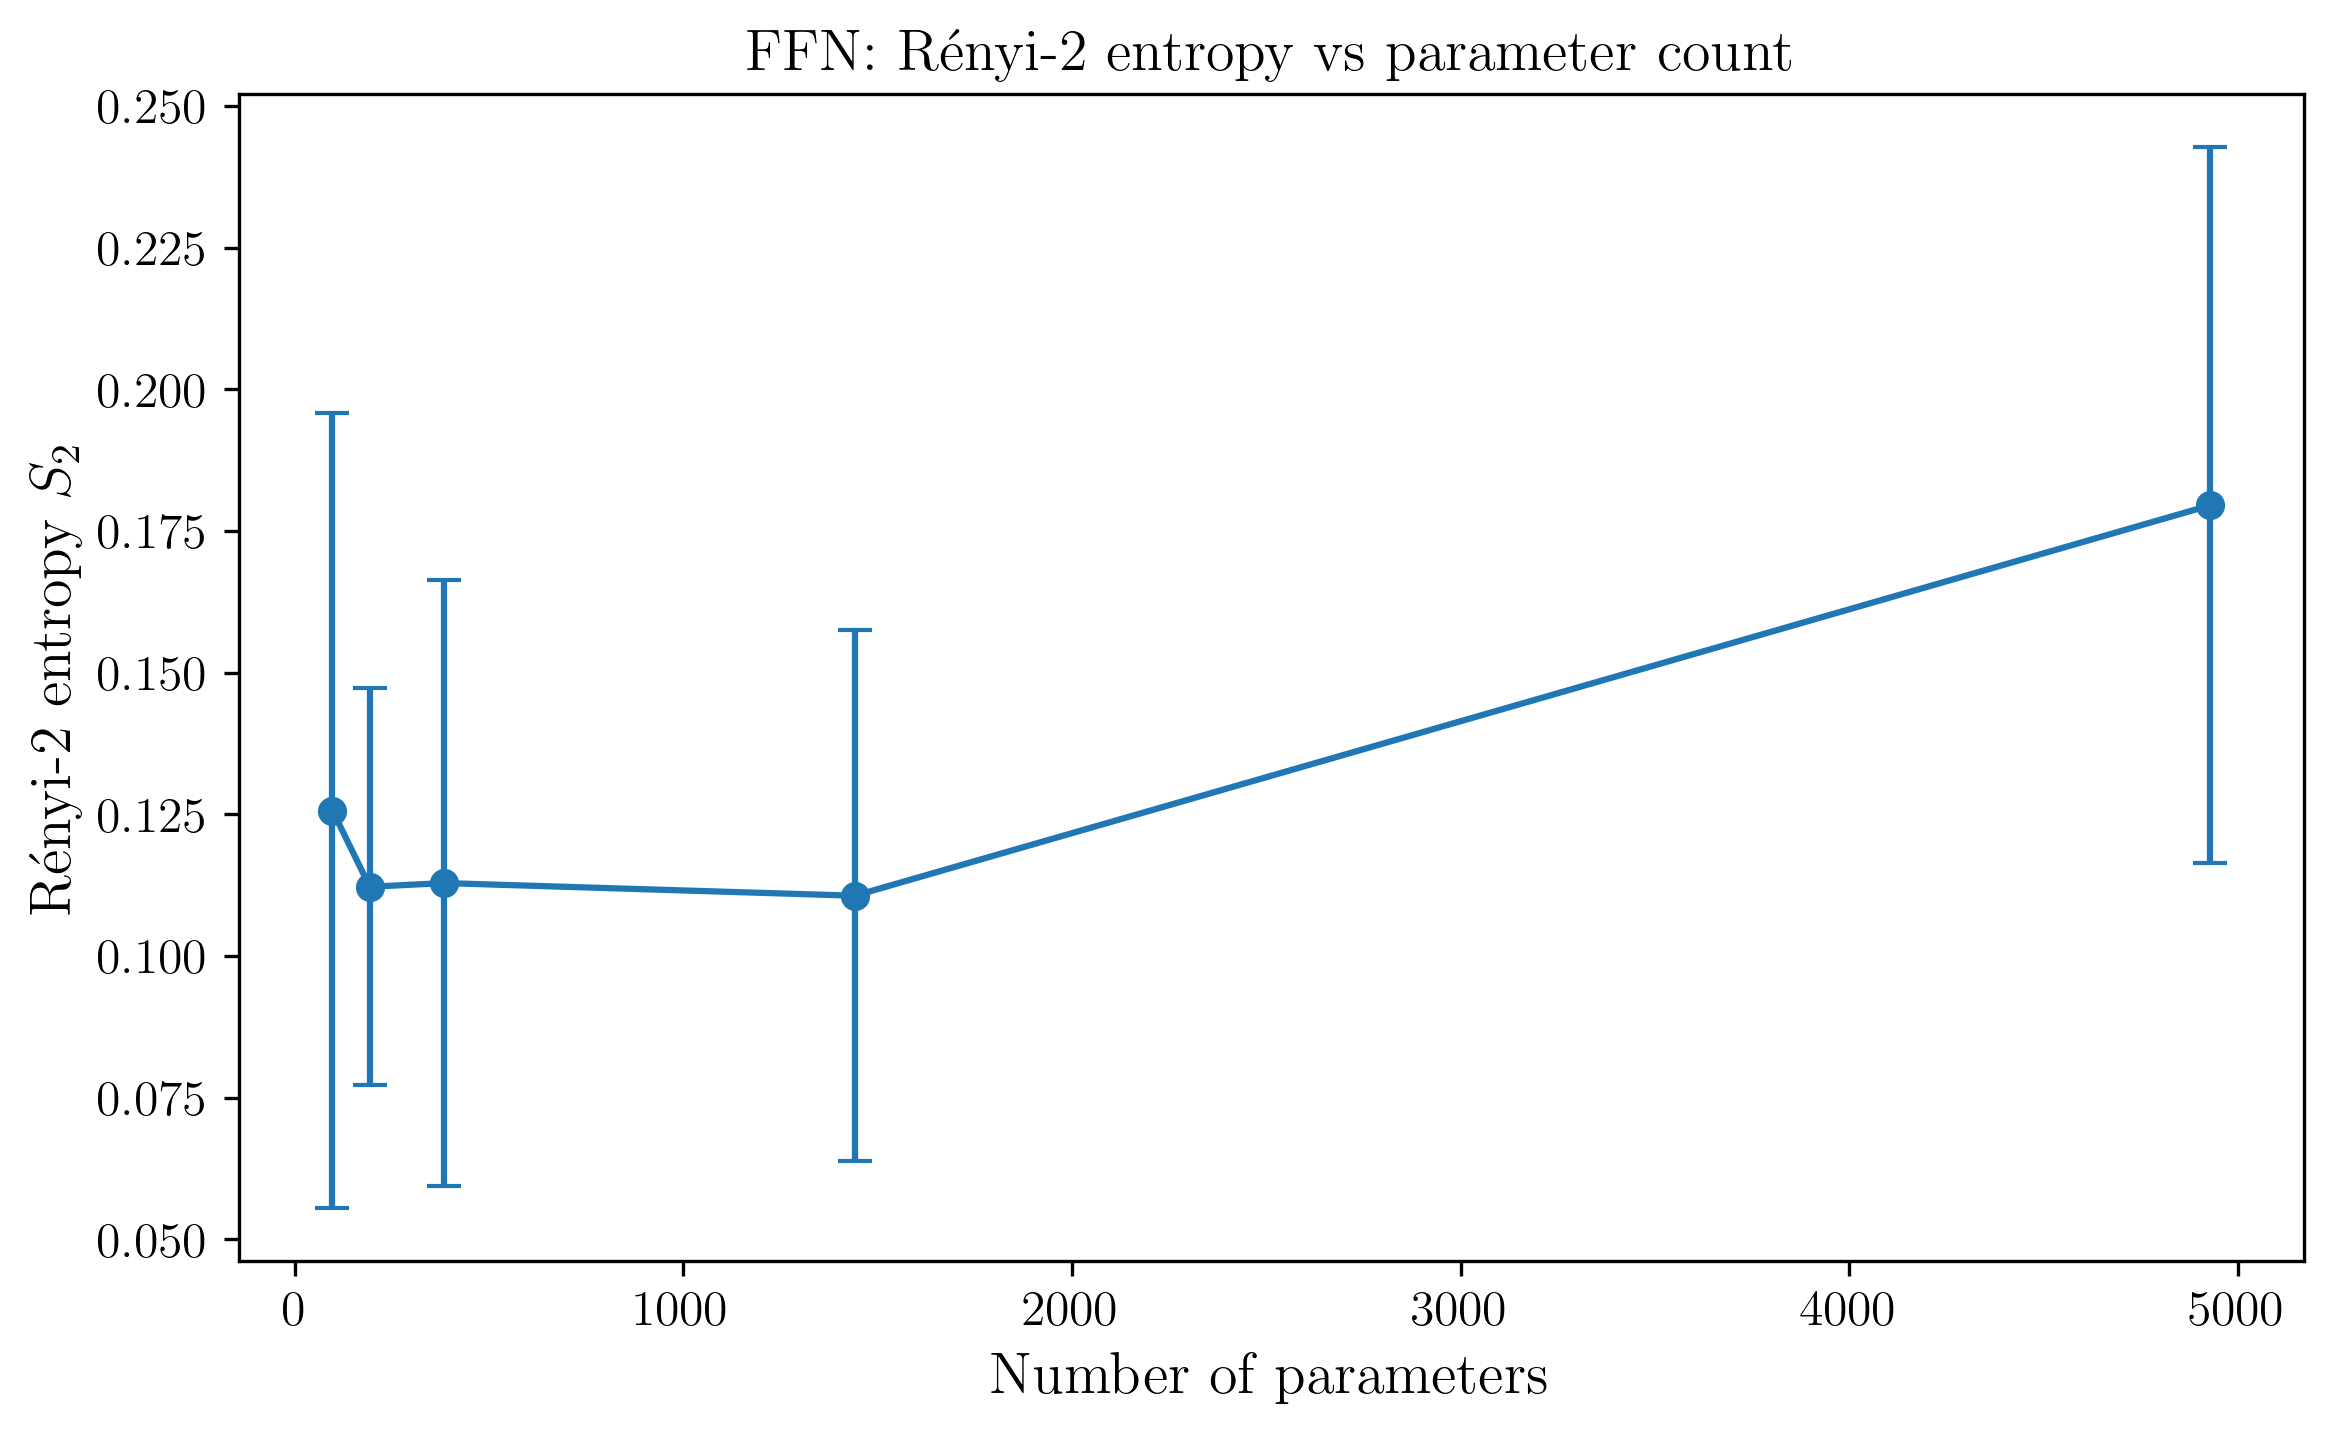

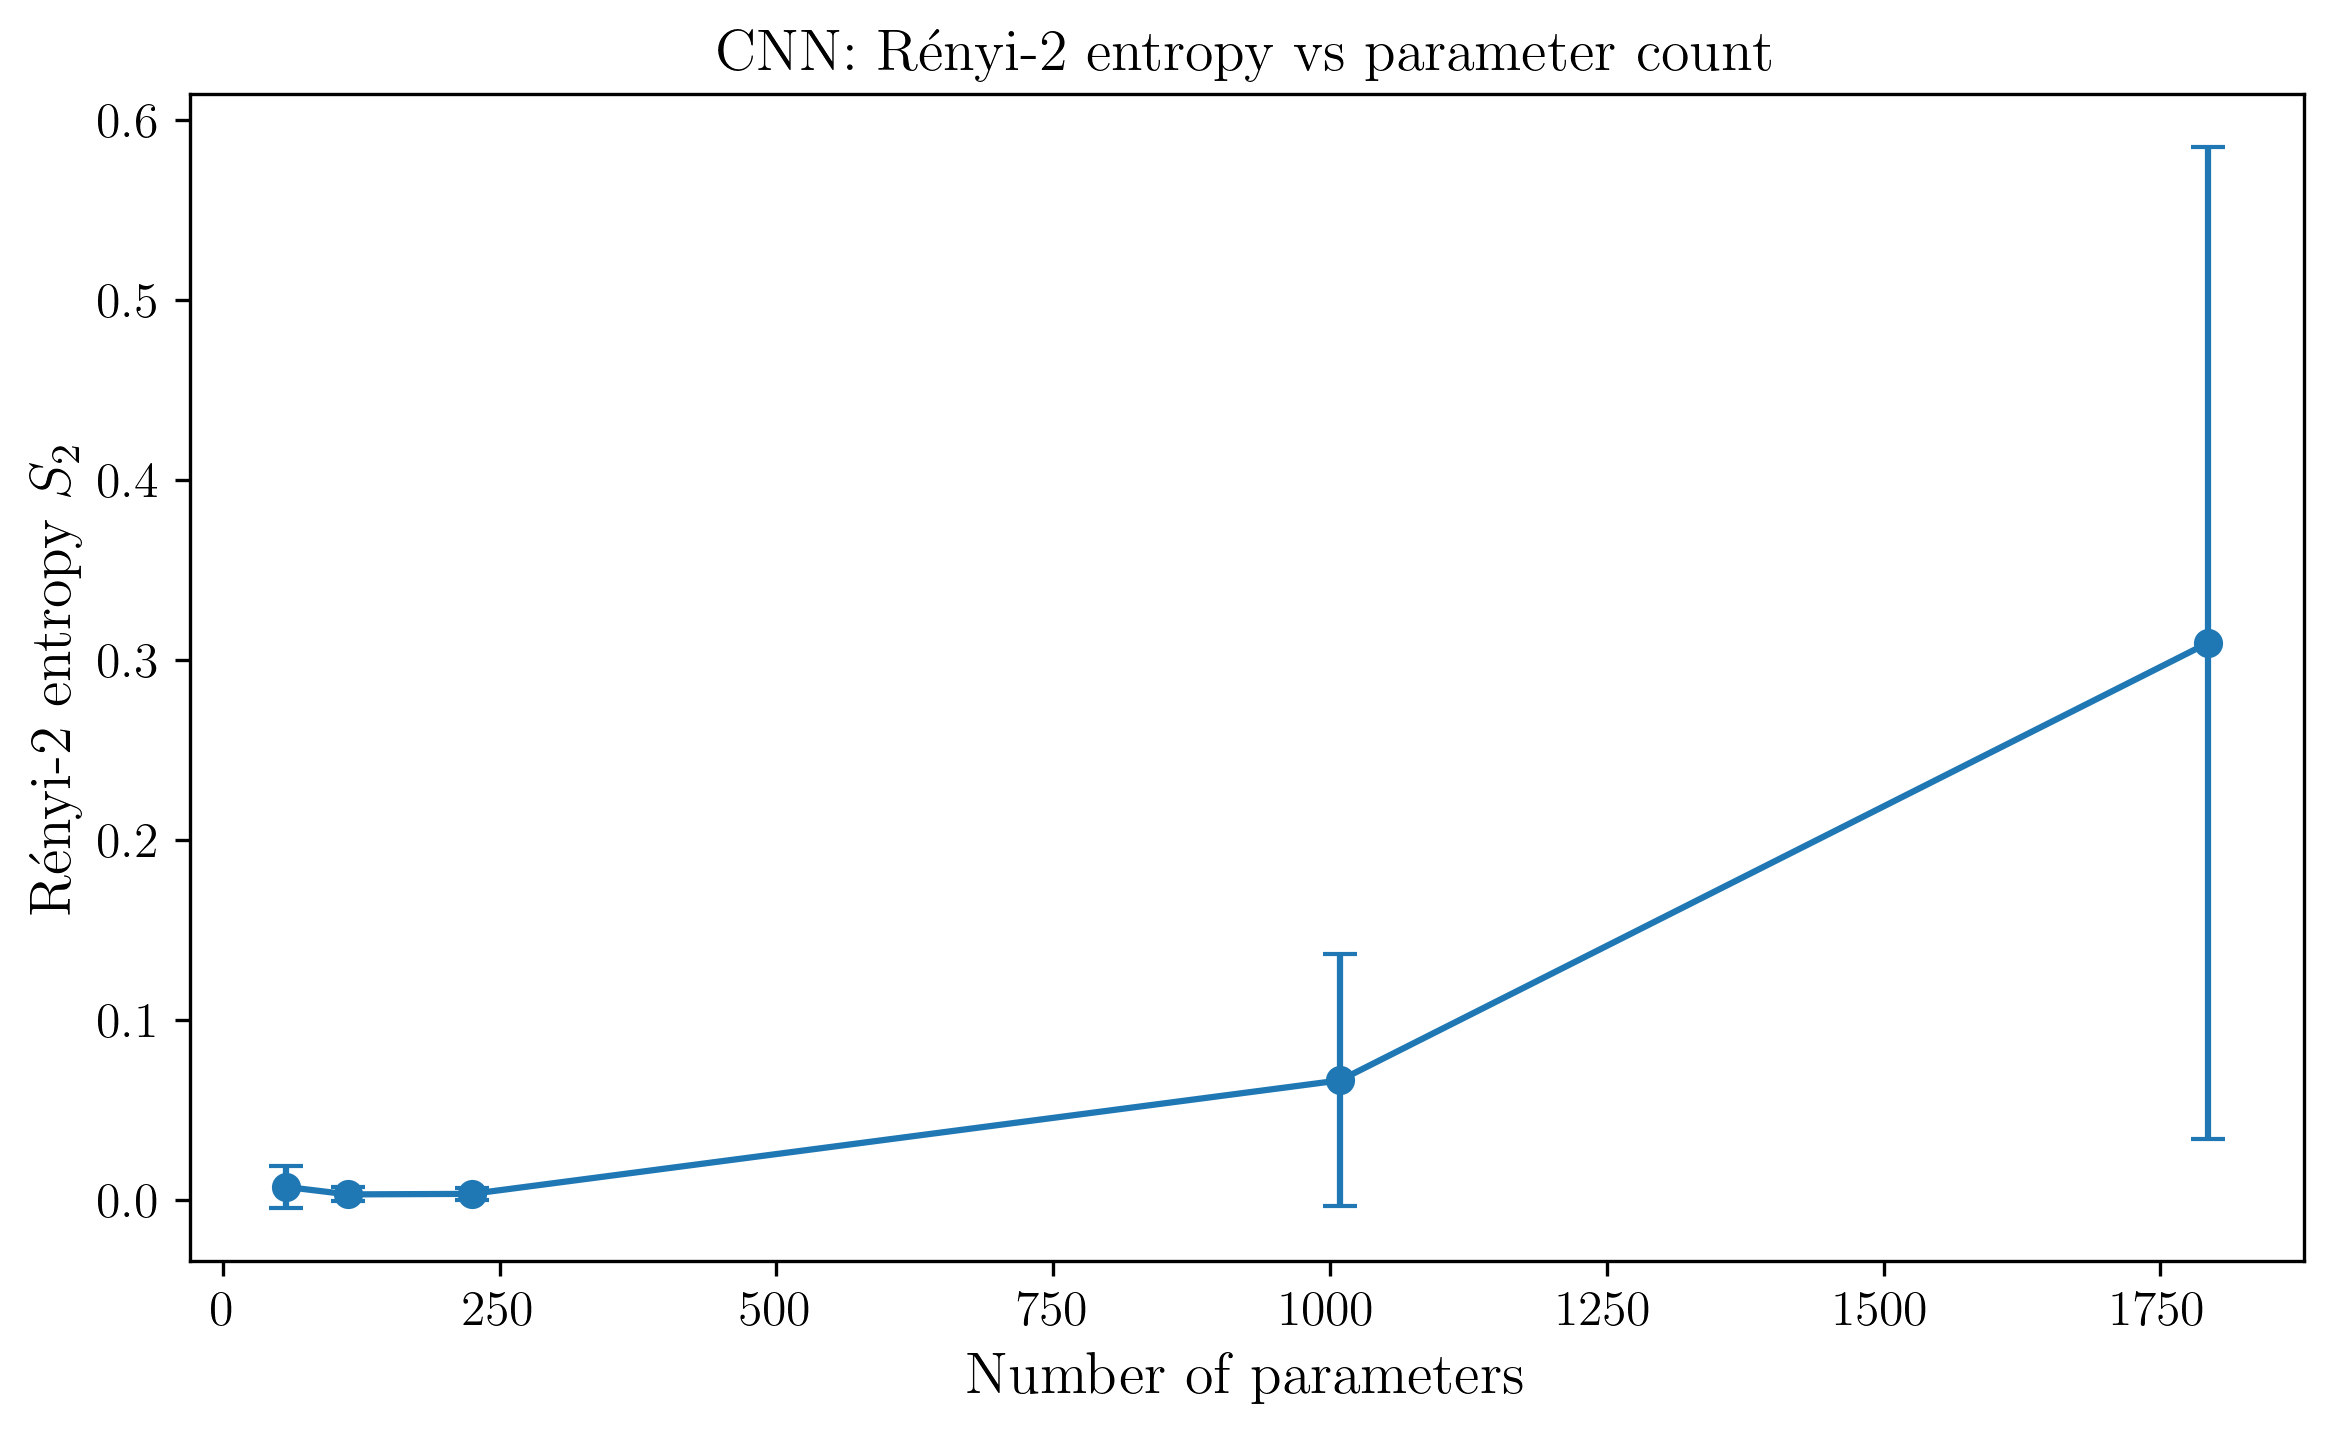

In [6]:
for model_name, scan in results_param.items():
    plot_entropy_vs_parameter_count(
        scan,
        title=f"{model_name}: Rényi-2 entropy vs parameter count"
    )